## Setup
Imports and plotting defaults.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score
)
import shap

# Reproducibility
np.random.seed(42)

# Plot styling
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_style("whitegrid")

print("All dependencies loaded successfully.")

C:\Users\Nikhil Rishi S\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All dependencies loaded successfully.


## Load data
Load the CSV and print basic stats.

In [2]:
# Load dataset
data = pd.read_csv(r'C:\Users\Nikhil Rishi S\Downloads\system-1 (1).csv')

print(f"Dataset Shape: {data.shape[0]:,} rows × {data.shape[1]} columns")
print(f"Time Span: {data['timestamp'].min()} to {data['timestamp'].max()} seconds")
print(f"Sampling Interval: ~{data['timestamp'].diff().median():.0f} seconds")
print(f"\nMissing Values:\n{data.isnull().sum()[data.isnull().sum() > 0]}")
if data.isnull().sum().sum() == 0:
    print("No missing values found.")

print(f"\nStatistical Summary:")
data.describe().round(4)


Dataset Shape: 85,749 rows × 24 columns
Time Span: 0 to 2592000 seconds
Sampling Interval: ~30 seconds

Missing Values:
Series([], dtype: int64)
No missing values found.

Statistical Summary:


,timestamp,load-1m,load-5m,load-15m,sys-mem-swap-total,sys-mem-swap-free,sys-mem-free,sys-mem-cache,sys-mem-buffered,sys-mem-available,...,sys-thermal,disk-io-time,disk-bytes-read,disk-bytes-written,disk-io-read,disk-io-write,cpu-iowait,cpu-system,cpu-user,server-up
count,8.574900e+04,85749.0000,85749.0000,85749.0000,8.574900e+04,8.574900e+04,8.574900e+04,8.574900e+04,8.574900e+04,8.574900e+04,...,85749.0000,85749.0000,8.574900e+04,8.574900e+04,85749.0000,85749.0000,85749.0000,85749.0000,85749.0000,85749.0000
mean,1.293647e+06,0.1297,0.1217,0.0980,1.695337e+10,1.695318e+10,4.234047e+09,8.778729e+09,1.740896e+09,1.559199e+10,...,0.6351,0.0075,9.378584e+02,4.141307e+04,0.0861,1.6497,0.0103,0.0338,0.0607,1.9999
std,7.506097e+05,0.2090,0.1125,0.0752,0.000000e+00,2.569240e+05,3.394397e+09,2.686202e+09,4.135548e+08,1.727195e+08,...,0.7781,0.0161,6.934765e+04,4.203652e+05,8.2364,3.8813,0.0151,0.0212,0.0808,0.0084
min,0.000000e+00,0.0000,0.0000,0.0000,1.695337e+10,1.695284e+10,1.702953e+08,4.818125e+08,1.795482e+08,1.425826e+10,...,0.0000,0.0000,0.000000e+00,0.000000e+00,0.0000,0.0000,0.0005,0.0105,0.0110,1.0000
25%,6.431100e+05,0.0200,0.0400,0.0400,1.695337e+10,1.695284e+10,1.806541e+09,7.406195e+09,1.317798e+09,1.544736e+10,...,0.0000,0.0042,0.000000e+00,6.553600e+03,0.0000,0.4500,0.0060,0.0225,0.0275,2.0000
50%,1.286220e+06,0.0700,0.0900,0.0900,1.695337e+10,1.695337e+10,2.382049e+09,9.988424e+09,1.985241e+09,1.566714e+10,...,0.0500,0.0056,0.000000e+00,1.085440e+04,0.0000,0.9000,0.0080,0.0255,0.0325,2.0000
75%,1.948890e+06,0.1600,0.1600,0.1500,1.695337e+10,1.695337e+10,6.405558e+09,1.066275e+10,2.056106e+09,1.571154e+10,...,1.5000,0.0078,0.000000e+00,2.109440e+04,0.0000,1.7000,0.0120,0.0340,0.0525,2.0000
max,2.592000e+06,5.0600,1.2700,0.5100,1.695337e+10,1.695337e+10,1.551792e+10,1.196882e+10,2.152661e+09,1.595769e+10,...,4.5500,0.9752,9.035162e+06,1.978962e+07,1106.7000,110.5000,0.9580,0.4645,1.4955,2.0000


## EDA
Quick plots to understand distributions and trends.

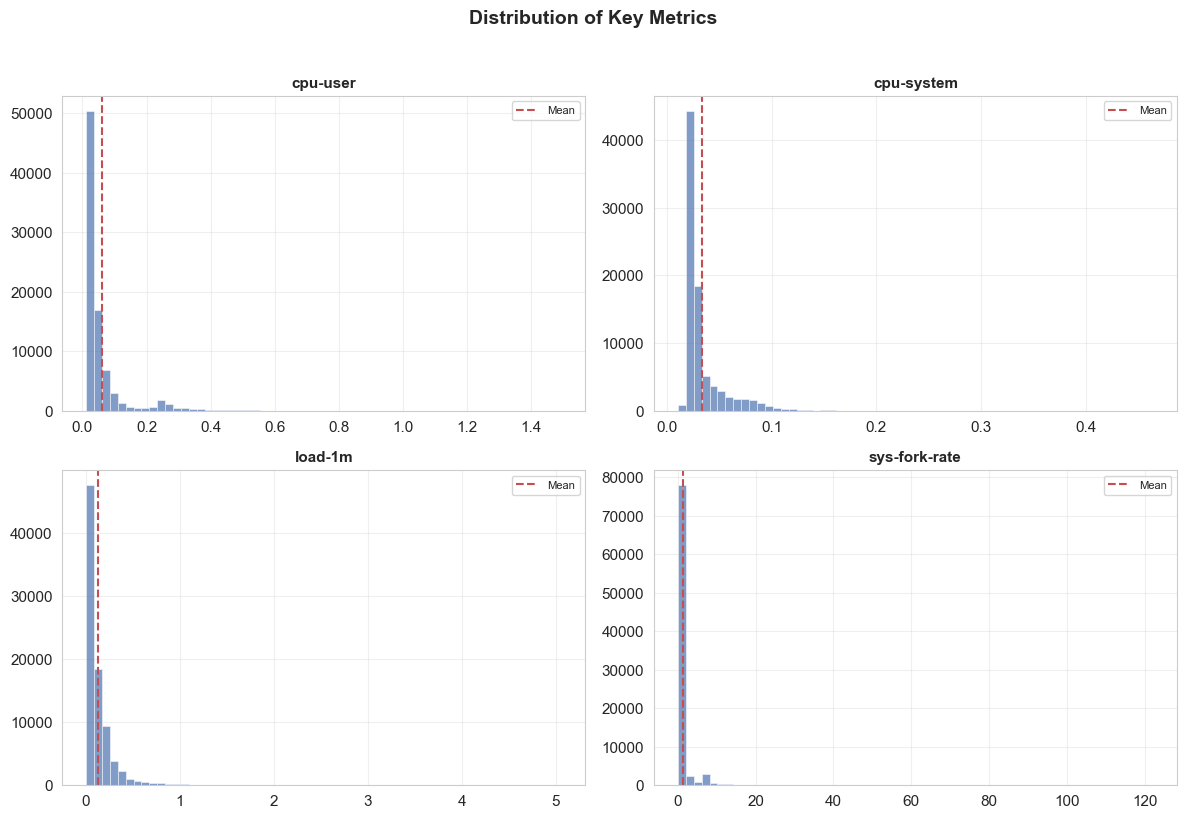

In [3]:
# Key metrics for a quick distribution snapshot
key_metrics = ['cpu-user', 'cpu-system', 'load-1m', 'sys-fork-rate']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(key_metrics):
    ax = axes[i]
    ax.hist(data[col], bins=60, color='#4C72B0', alpha=0.7, edgecolor='white', linewidth=0.5)
    ax.axvline(data[col].mean(), color='#C44E52', linestyle='--', linewidth=1.5, label='Mean')
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Distribution of Key Metrics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

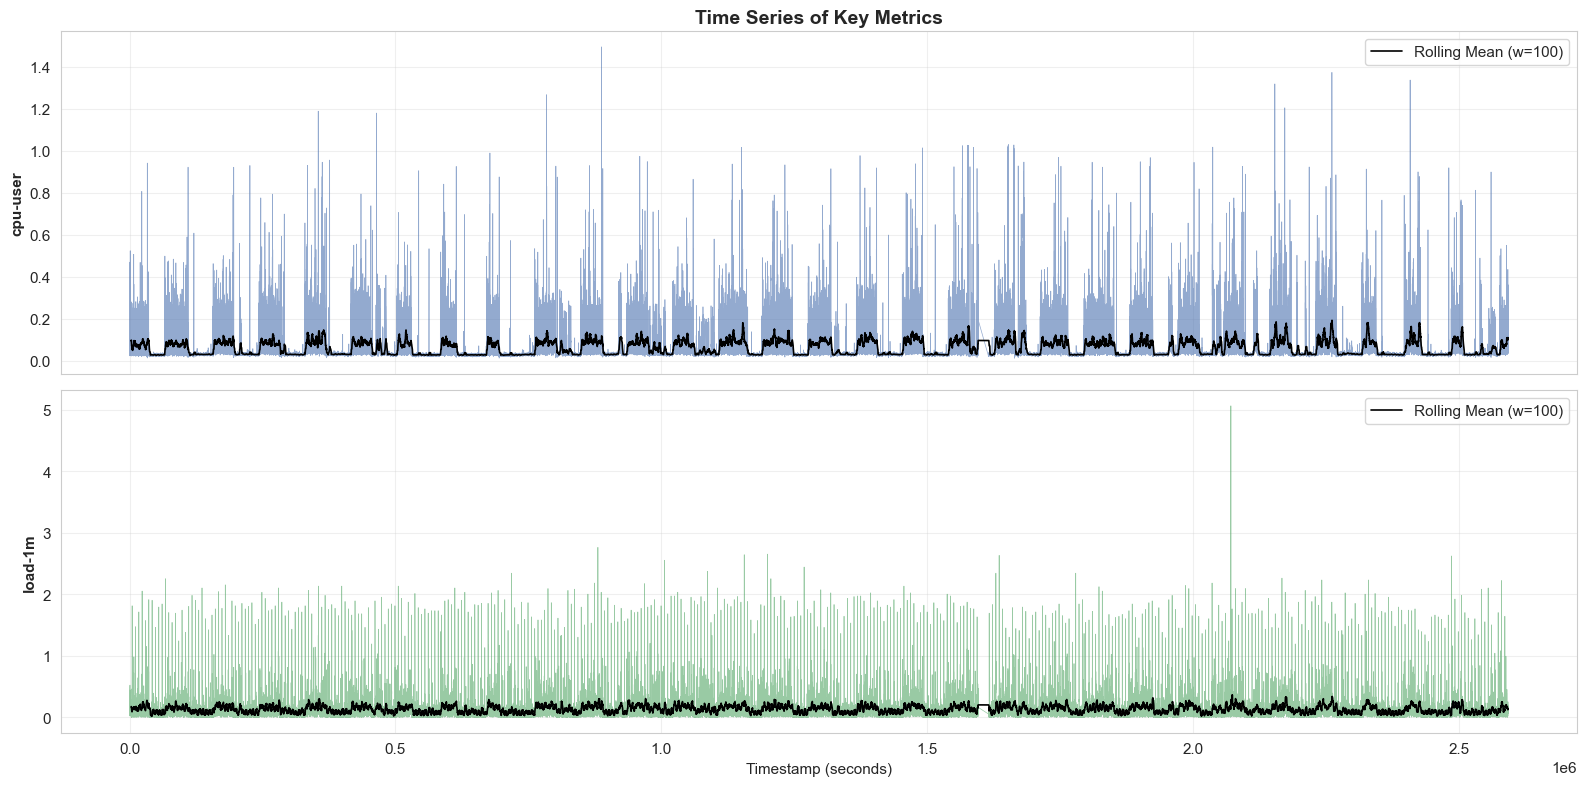

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

metrics_ts = ['cpu-user', 'load-1m']
colors = ['#4C72B0', '#55A868']

for i, (col, color) in enumerate(zip(metrics_ts, colors)):
    axes[i].plot(data['timestamp'], data[col], color=color, alpha=0.6, linewidth=0.5)
    rm = data[col].rolling(window=100).mean()
    axes[i].plot(data['timestamp'], rm, color='black', linewidth=1.2, label='Rolling Mean (w=100)')
    axes[i].set_ylabel(col, fontsize=11, fontweight='bold')
    axes[i].legend(loc='upper right')

axes[0].set_title('Time Series of Key Metrics', fontsize=14, fontweight='bold')
axes[-1].set_xlabel('Timestamp (seconds)', fontsize=11)
plt.tight_layout()
plt.show()

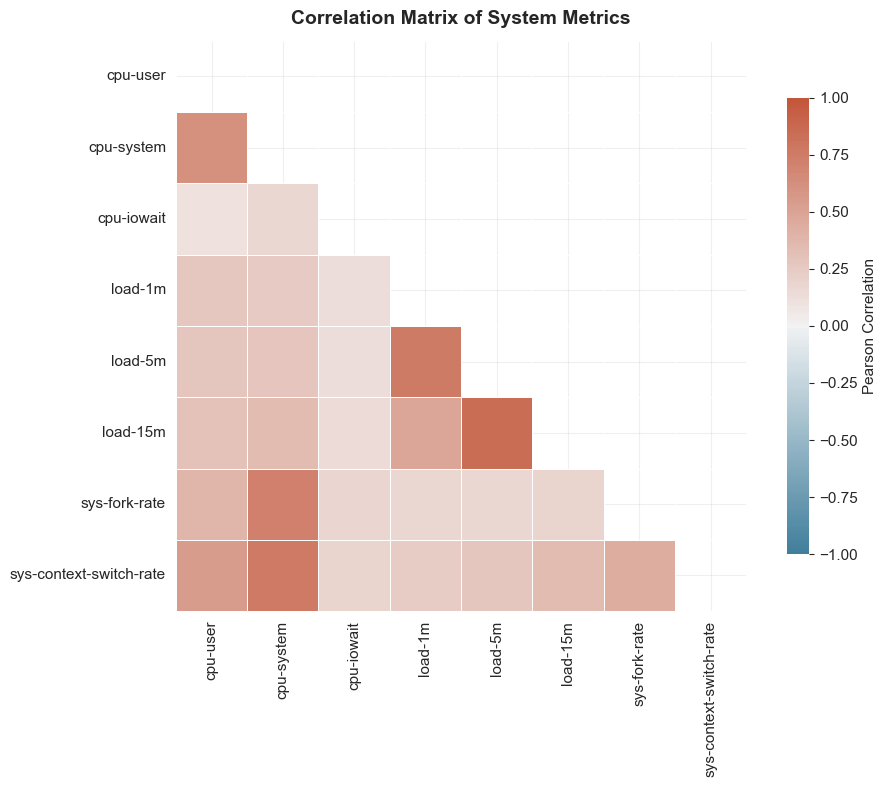

In [5]:
# Correlation heatmap (compact set of raw metrics)
corr_cols = [
    'cpu-user', 'cpu-system', 'cpu-iowait',
    'load-1m', 'load-5m', 'load-15m',
    'sys-fork-rate', 'sys-context-switch-rate'
]

corr_matrix = data[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(corr_matrix, mask=mask, cmap=cmap, vmin=-1, vmax=1, center=0,
            annot=False, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8, "label": "Pearson Correlation"},
            ax=ax)

ax.set_title('Correlation Matrix of System Metrics', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

## Features
Create compact time and interaction features.

In [6]:
# === BASE METRICS ===
data['cpu_total'] = data['cpu-user'] + data['cpu-system'] + data['cpu-iowait']
data['memory_pct'] = (data['sys-mem-total'] - data['sys-mem-available']) / data['sys-mem-total']
data['load_avg'] = (data['load-1m'] + data['load-5m'] + data['load-15m']) / 3.0
data['fork_rate'] = data['sys-fork-rate']

# === TIME FEATURES ===
WINDOW = 10
data['cpu_rolling_mean'] = data['cpu_total'].rolling(window=WINDOW).mean()
data['cpu_rolling_std'] = data['cpu_total'].rolling(window=WINDOW).std()
data['cpu_rate_of_change'] = data['cpu_total'].diff()
data['cpu_lag1'] = data['cpu_total'].shift(1)

period = 24 * 60 * 60  # daily seasonality proxy
data['time_sin'] = np.sin(2 * np.pi * data['timestamp'] / period)
data['time_cos'] = np.cos(2 * np.pi * data['timestamp'] / period)

# === CROSS-FEATURE INTERACTIONS ===
data['cpu_mem_interaction'] = data['cpu_total'] * data['memory_pct']
data['load_imbalance'] = data['load-1m'] / (data['load-15m'] + 1e-10)

# Drop NaN rows from rolling/diff/shift operations
data = data.dropna().reset_index(drop=True)

FEATURES = [
    'cpu_total', 'memory_pct', 'load_avg', 'fork_rate',
    'cpu_rolling_mean', 'cpu_rolling_std', 'cpu_rate_of_change', 'cpu_lag1',
    'time_sin', 'time_cos',
    'cpu_mem_interaction', 'load_imbalance'
]

print(f"Engineered {len(FEATURES)} features from {data.shape[1]} total columns")
print(f"Dataset after cleaning: {data.shape[0]:,} rows")
print("\nFeature List:")
for i, f in enumerate(FEATURES, 1):
    print(f"  {i:2d}. {f}")

Engineered 12 features from 36 total columns
Dataset after cleaning: 85,740 rows

Feature List:
   1. cpu_total
   2. memory_pct
   3. load_avg
   4. fork_rate
   5. cpu_rolling_mean
   6. cpu_rolling_std
   7. cpu_rate_of_change
   8. cpu_lag1
   9. time_sin
  10. time_cos
  11. cpu_mem_interaction
  12. load_imbalance


## Anomaly injection
Inject point, contextual, and drift anomalies with labels.

**Why this block exists**
Create synthetic anomalies so the models have labels for evaluation.
Inject three types: point (spike), contextual (odd during low activity), collective (slow drift).

In [7]:
# Sample a manageable subset for faster model training (every 5th point)
data_sampled = data.iloc[::5].copy().reset_index(drop=True)
print(f"Working dataset size: {data_sampled.shape[0]:,} rows")

# Initialize labels: 0 = normal, 1 = anomaly
data_sampled['label'] = 0
data_sampled['anomaly_type'] = 'normal'

# Store original values for injection
original_cpu = data_sampled['cpu_total'].copy()
original_fork = data_sampled['fork_rate'].copy()

n = len(data_sampled)

# -------------------------------------------------------------------
# TYPE 1: POINT ANOMALIES
# -------------------------------------------------------------------
n_point = int(n * 0.015)
point_indices = np.random.choice(data_sampled.index, size=n_point, replace=False)

cpu_std = data_sampled['cpu_total'].std()
fork_std = data_sampled['fork_rate'].std()

for idx in point_indices:
    spike_factor = np.random.uniform(3, 5)
    data_sampled.loc[idx, 'cpu_total'] += spike_factor * cpu_std
    data_sampled.loc[idx, 'fork_rate'] += spike_factor * fork_std
    data_sampled.loc[idx, 'label'] = 1
    data_sampled.loc[idx, 'anomaly_type'] = 'point'

# -------------------------------------------------------------------
# TYPE 2: CONTEXTUAL ANOMALIES
# -------------------------------------------------------------------
low_cpu_mask = original_cpu < original_cpu.quantile(0.25)
low_activity_indices = data_sampled.index[low_cpu_mask].tolist()

n_contextual = int(n * 0.015)
if len(low_activity_indices) >= n_contextual:
    contextual_indices = np.random.choice(low_activity_indices, size=n_contextual, replace=False)
else:
    contextual_indices = np.array(low_activity_indices)

high_cpu_values = original_cpu[original_cpu > original_cpu.quantile(0.90)].values
high_fork_values = original_fork[original_fork > original_fork.quantile(0.90)].values

for idx in contextual_indices:
    data_sampled.loc[idx, 'cpu_total'] = np.random.choice(high_cpu_values)
    data_sampled.loc[idx, 'fork_rate'] = np.random.choice(high_fork_values)
    if data_sampled.loc[idx, 'label'] == 0:
        data_sampled.loc[idx, 'label'] = 1
        data_sampled.loc[idx, 'anomaly_type'] = 'contextual'

# -------------------------------------------------------------------
# TYPE 3: COLLECTIVE ANOMALIES (GRADUAL DRIFT)
# -------------------------------------------------------------------
n_sequences = 8
used_indices = set(point_indices) | set(contextual_indices)
available_starts = [i for i in range(100, n - 30) if i not in used_indices]

if len(available_starts) >= n_sequences:
    drift_sequences = np.random.choice(available_starts, size=n_sequences, replace=False)
else:
    drift_sequences = np.array(available_starts)

for start in drift_sequences:
    seq_len = np.random.randint(15, 26)
    end = min(start + seq_len, n)
    drift_range = range(start, end)

    for j, idx in enumerate(drift_range):
        drift_factor = 1 + (j / seq_len) * 3
        data_sampled.loc[idx, 'cpu_total'] *= drift_factor
        data_sampled.loc[idx, 'memory_pct'] = min(data_sampled.loc[idx, 'memory_pct'] * drift_factor, 1.0)
        if data_sampled.loc[idx, 'label'] == 0:
            data_sampled.loc[idx, 'label'] = 1
            data_sampled.loc[idx, 'anomaly_type'] = 'collective'

# Recompute derived features after injection
WINDOW = 10

data_sampled['cpu_rolling_mean'] = data_sampled['cpu_total'].rolling(window=WINDOW).mean()
data_sampled['cpu_rolling_std'] = data_sampled['cpu_total'].rolling(window=WINDOW).std()
data_sampled['cpu_rate_of_change'] = data_sampled['cpu_total'].diff()
data_sampled['cpu_lag1'] = data_sampled['cpu_total'].shift(1)
data_sampled['cpu_mem_interaction'] = data_sampled['cpu_total'] * data_sampled['memory_pct']
data_sampled['load_imbalance'] = data_sampled['load-1m'] / (data_sampled['load-15m'] + 1e-10)

data_sampled = data_sampled.dropna().reset_index(drop=True)

# Summary
print("Anomaly Injection Summary:")
print("=" * 50)
for atype in ['normal', 'point', 'contextual', 'collective']:
    count = (data_sampled['anomaly_type'] == atype).sum()
    pct = count / len(data_sampled) * 100
    print(f"  {atype:15s}: {count:5d} samples ({pct:.2f}%)")
print(f"  {'TOTAL ANOMALIES':15s}: {data_sampled['label'].sum():5d} samples ({data_sampled['label'].mean()*100:.2f}%)")

Working dataset size: 17,148 rows
Anomaly Injection Summary:
  normal         : 16487 samples (96.20%)
  point          :   257 samples (1.50%)
  contextual     :   254 samples (1.48%)
  collective     :   141 samples (0.82%)
  TOTAL ANOMALIES:   652 samples (3.80%)


## Visualize anomalies
Scatter plots to see injected anomalies.

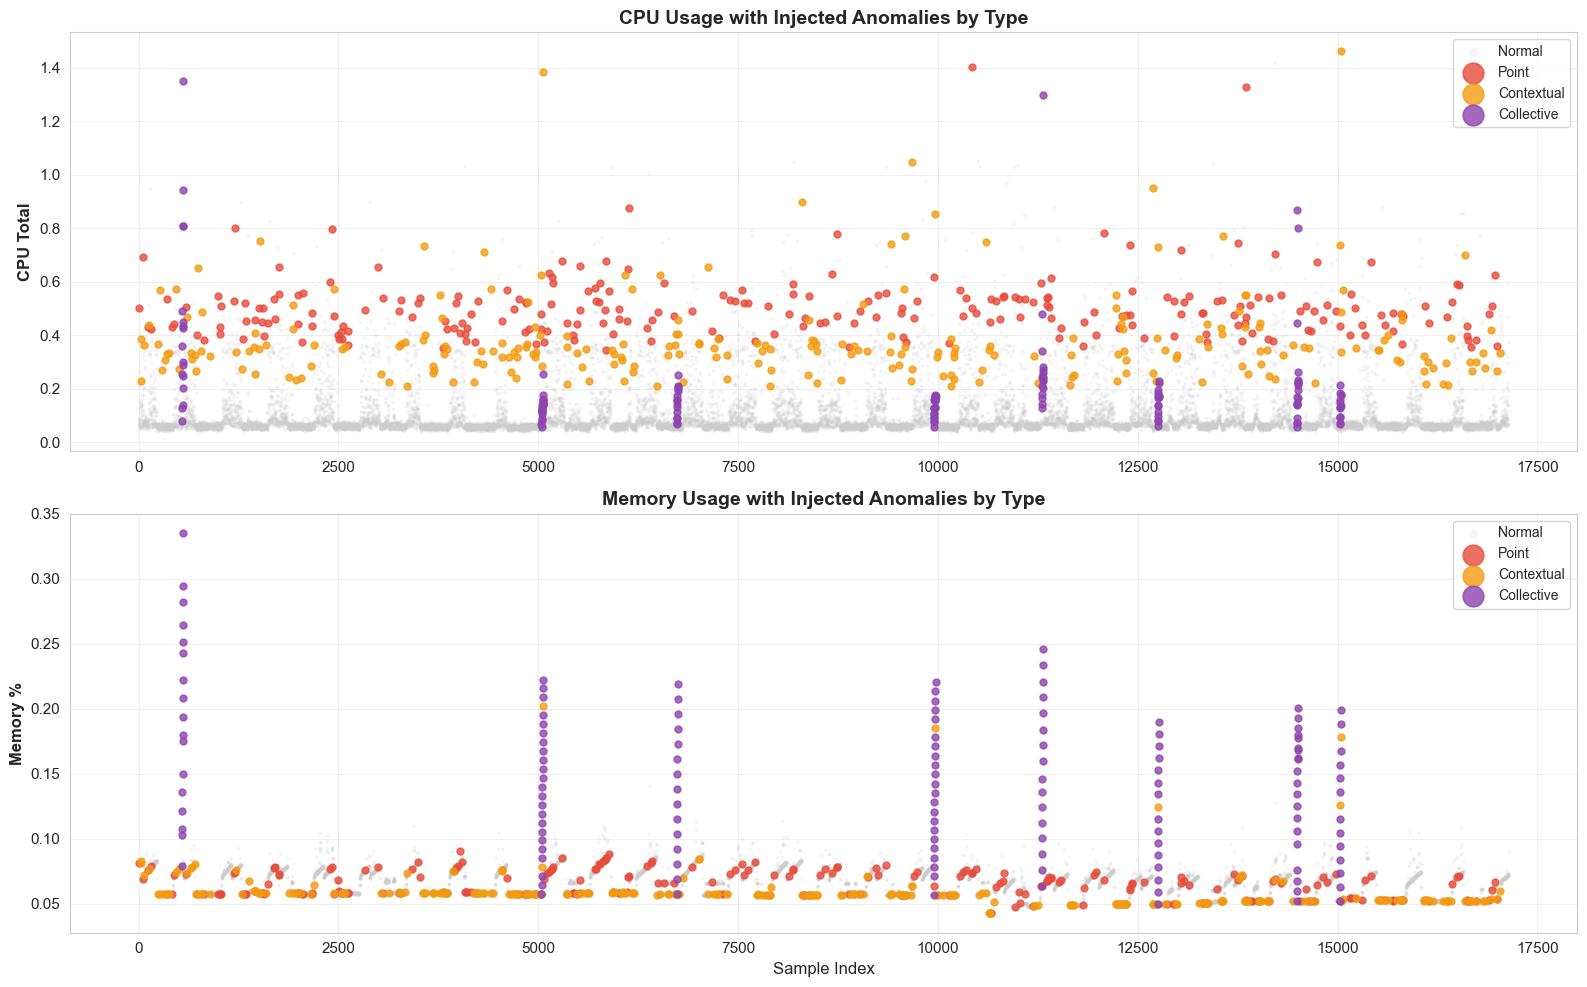

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

colors_map = {'normal': '#CCCCCC', 'point': '#E74C3C', 'contextual': '#F39C12', 'collective': '#8E44AD'}

# Plot 1: CPU with anomalies colored by type
for atype, color in colors_map.items():
    mask = data_sampled['anomaly_type'] == atype
    alpha = 0.15 if atype == 'normal' else 0.8
    size = 3 if atype == 'normal' else 25
    zorder = 1 if atype == 'normal' else 3
    axes[0].scatter(data_sampled.index[mask], data_sampled.loc[mask, 'cpu_total'],
                    c=color, s=size, alpha=alpha, label=atype.capitalize(), zorder=zorder)

axes[0].set_ylabel('CPU Total', fontsize=12, fontweight='bold')
axes[0].set_title('CPU Usage with Injected Anomalies by Type', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10, markerscale=3)

# Plot 2: Memory with anomalies
for atype, color in colors_map.items():
    mask = data_sampled['anomaly_type'] == atype
    alpha = 0.15 if atype == 'normal' else 0.8
    size = 3 if atype == 'normal' else 25
    zorder = 1 if atype == 'normal' else 3
    axes[1].scatter(data_sampled.index[mask], data_sampled.loc[mask, 'memory_pct'],
                    c=color, s=size, alpha=alpha, label=atype.capitalize(), zorder=zorder)

axes[1].set_ylabel('Memory %', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sample Index', fontsize=12)
axes[1].set_title('Memory Usage with Injected Anomalies by Type', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10, markerscale=3)

plt.tight_layout()
plt.show()


## Anomaly report
Human-readable list of the most severe anomalies.

In [17]:
# Human-readable anomaly report
report_cols = [
    'timestamp', 'anomaly_type', 'cpu_total', 'memory_pct', 'fork_rate', 'load_avg'
 ]
report_df = data_sampled.loc[data_sampled['label'] == 1, report_cols].copy()

def zscore(series):
    return (series - series.mean()) / (series.std() + 1e-10)

if report_df.empty:
    print("Anomaly Report")
    print("No anomalies found.")
else:
    report_df['severity'] = (
        zscore(report_df['cpu_total']).abs() +
        zscore(report_df['fork_rate']).abs() +
        zscore(report_df['memory_pct']).abs()
    )
    report_df = report_df.sort_values('severity', ascending=False)

    print("Anomaly Report (top 10 by severity)")
    print(report_df.head(10).to_string(index=False, float_format="%.4f"))

Anomaly Report (top 10 by severity)
 timestamp anomaly_type  cpu_total  memory_pct  fork_rate  load_avg  severity
     85920   collective     1.3516      0.3354     0.6500    0.1867   12.0040
   1976430        point     0.7196      0.0710    49.5008    0.3133    9.2224
   2276880   contextual     1.4620      0.1780     3.0000    0.0400    8.6298
   1718430   collective     1.2996      0.2334     6.1500    0.1200    8.4764
    760920   contextual     1.3834      0.2020     6.8000    0.0200    8.0927
     85470   collective     0.9438      0.2647     8.3000    0.2333    7.1068
     85770   collective     0.3009      0.2947     0.8000    0.1400    6.5348
   1924680   contextual     0.9510      0.0499    24.5500    0.0833    6.5148
     85170   collective     0.8103      0.2428    11.0500    0.3533    6.4049
    365520        point     0.7977      0.0787    30.8262    0.1100    6.1737


## Prepare data
Scale features and build matrices for models.

In [9]:
# Prepare feature matrix
X = data_sampled[FEATURES].copy()
y_true = data_sampled['label'].values
anomaly_types = data_sampled['anomaly_type'].values

# Scale features using StandardScaler (zero mean, unit variance)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Feature matrix shape: {X_scaled.shape}")
print(f"Anomaly ratio: {y_true.mean()*100:.2f}%")
print(f"Class distribution: Normal={sum(y_true==0):,}, Anomaly={sum(y_true==1):,}")


Feature matrix shape: (17139, 12)
Anomaly ratio: 3.80%
Class distribution: Normal=16,487, Anomaly=652


## Models
Train baseline anomaly detectors.

In [10]:
# -------------------------------------------------------------------
# BASELINE 1: Isolation Forest
# -------------------------------------------------------------------
iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    max_features=0.8,
    random_state=42
)
iso_scores_raw = -iso_model.fit(X_scaled).decision_function(X_scaled)
iso_pred = np.where(iso_model.predict(X_scaled) == -1, 1, 0)

In [11]:
# -------------------------------------------------------------------
# BASELINE 2: Local Outlier Factor
# -------------------------------------------------------------------
lof_model = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05,
    novelty=False
)
lof_pred = lof_model.fit_predict(X_scaled)
lof_scores_raw = -lof_model.negative_outlier_factor_
lof_pred = np.where(lof_pred == -1, 1, 0)

In [13]:
# -------------------------------------------------------------------
# BASELINE 3: One-Class SVM
# -------------------------------------------------------------------
svm_train_size = min(5000, len(X_scaled))
svm_indices = np.random.choice(len(X_scaled), size=svm_train_size, replace=False)
X_svm_train = X_scaled[svm_indices]

svm_model = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
svm_model.fit(X_svm_train)

svm_scores_raw = -svm_model.decision_function(X_scaled)
svm_pred = np.where(svm_model.predict(X_scaled) == -1, 1, 0)

In [13]:
# -------------------------------------------------------------------
# BASELINE 4: DBSCAN (Density-Based)
# -------------------------------------------------------------------
from sklearn.neighbors import NearestNeighbors

k = 5  # min_samples
nn = NearestNeighbors(n_neighbors=k)
nn.fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

# Use the 95th percentile as a simple eps heuristic
eps_value = np.percentile(k_distances, 95)

# Run DBSCAN
dbscan = DBSCAN(eps=eps_value, min_samples=k)
dbscan_labels = dbscan.fit_predict(X_scaled)

# In DBSCAN: label = -1 means noise (anomaly)
dbscan_pred = (dbscan_labels == -1).astype(int)
dbscan_scores_raw = distances[:, -1]

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = np.sum(dbscan_labels == -1)

print("DBSCAN Results:")
print(f"  eps = {eps_value:.4f}, min_samples = {k}")
print(f"  Clusters found: {n_clusters}")
print(f"  Noise points (anomalies): {n_noise} ({n_noise/len(dbscan_labels)*100:.2f}%)")

DBSCAN Results:
  eps = 1.6383, min_samples = 5
  Clusters found: 9
  Noise points (anomalies): 587 (3.42%)


## Results
Compare metrics across models.

In [14]:
# Collect predictions
all_models = {
    'Isolation Forest': iso_pred,
    'LOF': lof_pred,
    'One-Class SVM': svm_pred,
    'DBSCAN': dbscan_pred
}

# Build results table
results_rows = []
for name, pred in all_models.items():
    results_rows.append({
        'Model': name,
        'Precision': precision_score(y_true, pred),
        'Recall': recall_score(y_true, pred),
        'F1-Score': f1_score(y_true, pred),
        'AUC-ROC': roc_auc_score(y_true, pred)
    })

results_df = pd.DataFrame(results_rows)
results_df = results_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("=" * 70)
print("MODEL COMPARISON RESULTS")
print("=" * 70)
print(results_df.to_string(index=False, float_format='%.4f'))
print("=" * 70)

best = results_df.iloc[0]
print(f"\nBest Model: {best['Model']} (F1={best['F1-Score']:.4f})")

MODEL COMPARISON RESULTS
           Model  Precision  Recall  F1-Score  AUC-ROC
Isolation Forest     0.4201  0.5521    0.4771   0.7610
   One-Class SVM     0.2621  0.3834    0.3113   0.6704
          DBSCAN     0.3152  0.2837    0.2986   0.6297
             LOF     0.1634  0.2147    0.1856   0.5856

Best Model: Isolation Forest (F1=0.4771)


## ROC and PR curves
Plot ROC and precision-recall curves.

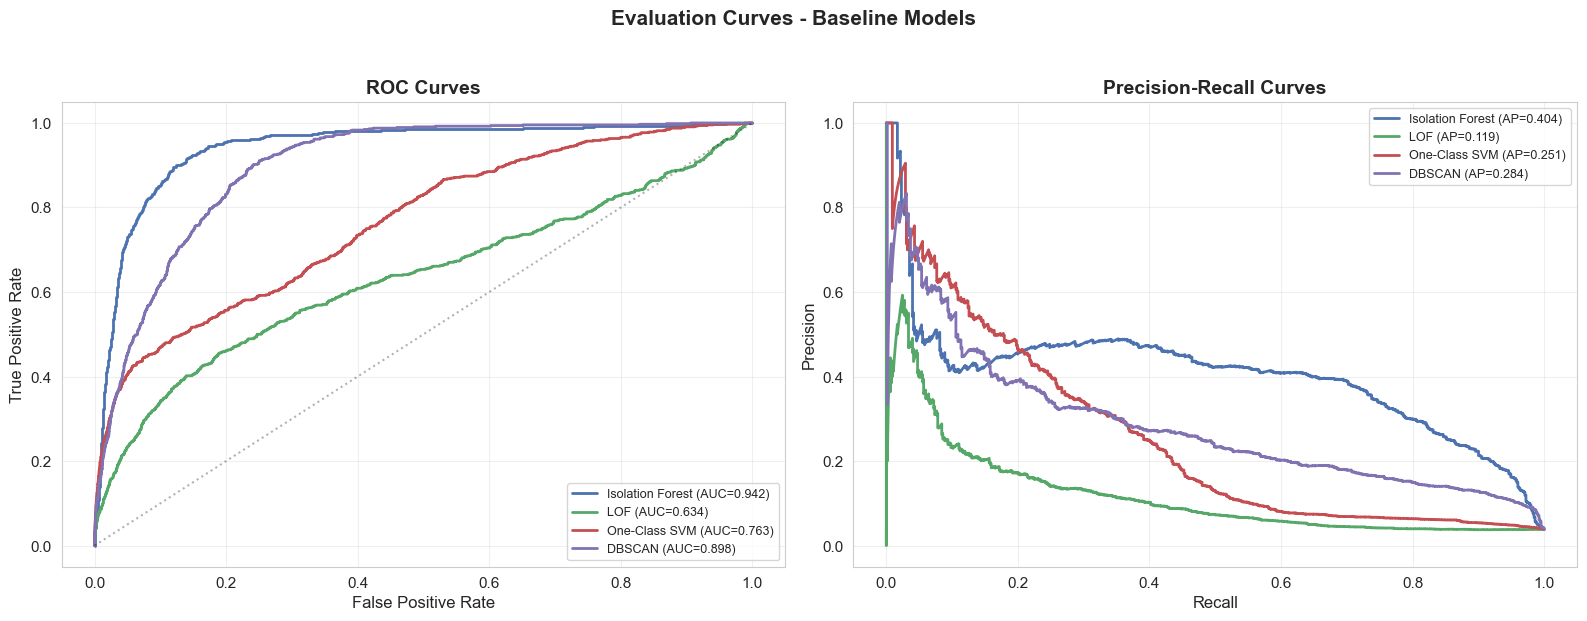

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

all_scores_for_curves = {
    'Isolation Forest': iso_scores_raw,
    'LOF': lof_scores_raw,
    'One-Class SVM': svm_scores_raw,
    'DBSCAN': dbscan_scores_raw
}

# ROC Curves
for i, (name, scores) in enumerate(all_scores_for_curves.items()):
    s_min, s_max = scores.min(), scores.max()
    s_norm = (scores - s_min) / (s_max - s_min + 1e-10)

    fpr, tpr, _ = roc_curve(y_true, s_norm)
    auc = roc_auc_score(y_true, s_norm)
    axes[0].plot(fpr, tpr, color=colors[i], linewidth=2,
                 label=f'{name} (AUC={auc:.3f})')

axes[0].plot([0, 1], [0, 1], 'k:', alpha=0.3)
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curves', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=9, loc='lower right')

# Precision-Recall Curves
for i, (name, scores) in enumerate(all_scores_for_curves.items()):
    s_min, s_max = scores.min(), scores.max()
    s_norm = (scores - s_min) / (s_max - s_min + 1e-10)

    prec, rec, _ = precision_recall_curve(y_true, s_norm)
    ap = average_precision_score(y_true, s_norm)
    axes[1].plot(rec, prec, color=colors[i], linewidth=2,
                 label=f'{name} (AP={ap:.3f})')

axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curves', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=9, loc='upper right')

plt.suptitle('Evaluation Curves - Baseline Models', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

## SHAP
Explain Isolation Forest feature contributions.

SHAP Summary Plot: Global Feature Importance


C:\Users\Nikhil Rishi S\AppData\Local\Temp\ipykernel_16064\3784577159.py:21: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


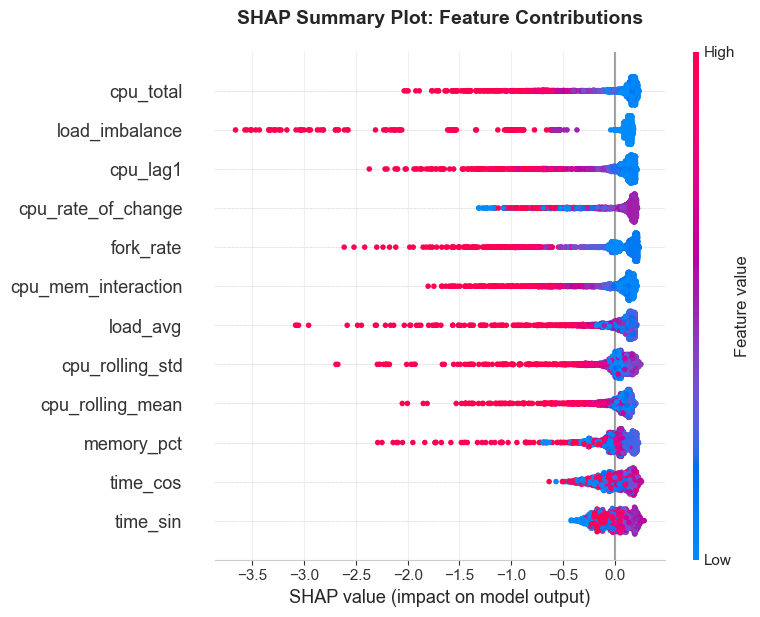


Top 5 Features by Mean |SHAP|:
  1. cpu_total                 | mean |SHAP| = 0.2576
  2. load_imbalance            | mean |SHAP| = 0.2508
  3. cpu_lag1                  | mean |SHAP| = 0.2281
  4. cpu_rate_of_change        | mean |SHAP| = 0.2252
  5. fork_rate                 | mean |SHAP| = 0.2239


In [16]:
# =====================================================
# SHAP EXPLAINABILITY FOR ISOLATION FOREST
# =====================================================

iso_for_shap = IsolationForest(
    contamination=0.05, n_estimators=200, random_state=42
)
iso_for_shap.fit(X_scaled)

explainer = shap.TreeExplainer(iso_for_shap)

shap_sample_size = min(2000, len(X_scaled))
shap_sample_idx = np.random.choice(len(X_scaled), shap_sample_size, replace=False)
X_shap_sample = X_scaled[shap_sample_idx]

shap_values = explainer.shap_values(X_shap_sample)

print("SHAP Summary Plot: Global Feature Importance")

plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values, X_shap_sample,
    feature_names=FEATURES,
    show=False,
    max_display=len(FEATURES)
)
plt.title('SHAP Summary Plot: Feature Contributions',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

mean_abs = np.abs(shap_values).mean(axis=0)
sorted_features = sorted(zip(FEATURES, mean_abs), key=lambda x: -x[1])
print("\nTop 5 Features by Mean |SHAP|:")
for rank, (feat, imp) in enumerate(sorted_features[:5], 1):
    print(f"  {rank}. {feat:25s} | mean |SHAP| = {imp:.4f}")